<a href="https://colab.research.google.com/github/PrathyushaMyla2005/google-colab/blob/main/Vast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [169]:
import pandas as pd
import numpy as np
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [112]:
data_test = pd.read_csv("/content/VAST_test.csv")
data_train = pd.read_csv("/content/VAST_train_11k.csv")
data_val = pd.read_csv("/content/VAST_val.csv")
print(data_test.head())
print("Dataset shape:", data_test.shape)
print(data_train.head())
print("Dataset shape:", data_train.shape)
print(data_val.head())
print("Dataset shape:", data_val.shape)

                                               Tweet             Target 1  \
0  I totally agree with this premise. As a younge...        nuclear power   
1  I totally agree with this premise. As a younge...        nuclear power   
2  Who is the mayor of N.Y. to assume he has the ...    illegal immigrant   
3  Who is the mayor of N.Y. to assume he has the ...  illegal immigration   
4  Who is the mayor of N.Y. to assume he has the ...            immigrant   

  Stance 1  seen?  
0    FAVOR      0  
1    FAVOR      0  
2  AGAINST      1  
3  AGAINST      1  
4  AGAINST      1  
Dataset shape: (3006, 4)
                                               Tweet                Target 1  \
0  Regulation of corporations has been subverted ...                 company   
1  Regulation of corporations has been subverted ...              regulation   
2  Regulation of corporations has been subverted ...    corporate regulation   
3  Regulation of corporations has been subverted ...  regulation corpora

In [113]:
from scipy.sparse import data
data_train.columns = data_train.columns.str.strip()

print("Columns:", data_train.columns)
data_val.columns = data_val.columns.str.strip()

print("Columns:", data_val.columns)
data_test.columns = data_test.columns.str.strip()

print("Columns:", data_test.columns)

Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')
Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')
Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')


In [114]:
data_train['input_text'] = data_train['Tweet'] + " target " +data_train['Target 1']

print(data_train[['input_text']].head())
data_val['input_text'] = data_train['Tweet'] + " target " +data_val['Target 1']

print(data_val[['input_text']].head())
data_test['input_text'] = data_test['Tweet'] + " target " +data_test['Target 1']

print(data_test[['input_text']].head())

                                          input_text
0  Regulation of corporations has been subverted ...
1  Regulation of corporations has been subverted ...
2  Regulation of corporations has been subverted ...
3  Regulation of corporations has been subverted ...
4  Absolutely it's needs to be defined and regula...
                                          input_text
0  Regulation of corporations has been subverted ...
1  Regulation of corporations has been subverted ...
2  Regulation of corporations has been subverted ...
3  Regulation of corporations has been subverted ...
4  Absolutely it's needs to be defined and regula...
                                          input_text
0  I totally agree with this premise. As a younge...
1  I totally agree with this premise. As a younge...
2  Who is the mayor of N.Y. to assume he has the ...
3  Who is the mayor of N.Y. to assume he has the ...
4  Who is the mayor of N.Y. to assume he has the ...


In [115]:
data_train['input_text'] = data_train['input_text'].apply(clean_text)
data_val['input_text'] = data_val['input_text'].apply(clean_text)
data_test['input_text'] = data_test['input_text'].apply(clean_text)

In [116]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [117]:
print(data_train.columns)
print(data_val.columns)
print(data_test.columns)

Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')
Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')
Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')


In [118]:
encoder = LabelEncoder()

data_train['label'] = encoder.fit_transform(data_train['Stance 1'])

print(data_train[['Stance 1','label']].head())

data_val['label'] = encoder.fit_transform(data_val['Stance 1'])

print(data_val[['Stance 1','label']].head())
data_test['label'] = encoder.fit_transform(data_test['Stance 1'])

print(data_test[['Stance 1','label']].head())

  Stance 1  label
0  AGAINST      0
1  AGAINST      0
2  AGAINST      0
3  AGAINST      0
4  AGAINST      0
  Stance 1  label
0  AGAINST      0
1  AGAINST      0
2    FAVOR      1
3  AGAINST      0
4  AGAINST      0
  Stance 1  label
0    FAVOR      1
1    FAVOR      1
2  AGAINST      0
3  AGAINST      0
4  AGAINST      0


In [119]:
tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(data_train['input_text'])

sequences = tokenizer.texts_to_sequences(data_train['input_text'])
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(data_val['input_text'])
sequences_val = tokenizer.texts_to_sequences(data_val['input_text'])
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(data_test['input_text'])
sequences_test = tokenizer.texts_to_sequences(data_test['input_text'])

In [120]:
encoder = LabelEncoder()

data_train['label'] = encoder.fit_transform(data_train['Stance 1'])
data_val['label'] = encoder.transform(data_val['Stance 1'])
data_test['label'] = encoder.transform(data_test['Stance 1'])

In [121]:
print(sequences[0])

[454, 4, 549, 48, 73, 11874, 32, 549, 214, 8, 5939, 549, 12, 14, 3123, 2, 2404, 549, 8, 12, 351, 165, 2, 1305, 2590, 12, 351, 165, 2, 11875, 5, 228, 791, 8, 46, 5231, 1, 108, 124, 29, 549, 3, 21, 11876, 308, 15, 3171, 6, 1, 333, 716, 27, 885, 7, 2, 1252, 11, 414]


In [122]:
max_len = 100

X = pad_sequences(sequences, maxlen=max_len)

In [123]:
X_train = pad_sequences(tokenizer.texts_to_sequences(data_train['input_text']), maxlen=max_len)
X_test  = pad_sequences(tokenizer.texts_to_sequences(data_test['input_text']), maxlen=max_len)
y_train = data_train['label']
y_test  = data_test['label']

In [124]:
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("Max sequence length:", max_len)

Vocabulary size: 9357
Max sequence length: 100


load glove

In [69]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-31 09:33:34--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-31 09:33:34--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-31 09:33:34--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [ ]:
!unzip glove.6B.zip

In [125]:
import numpy as np

embedding_dim = 100
embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:

    for line in f:

        values = line.split()

        word = values[0]

        vector = np.asarray(values[1:], dtype='float32')

        embeddings_index[word] = vector

print("Total words in GloVe:", len(embeddings_index))

Total words in GloVe: 400000


In [126]:
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():

    vector = embeddings_index.get(word)

    if vector is not None:

        embedding_matrix[i] = vector

In [316]:
print(len(X))
print(len(y))

11305
2062


In [317]:
X = pad_sequences(
    tokenizer.texts_to_sequences(data_train['input_text']),
    maxlen=max_len
)

y = data_train['label']   # ✅ same dataset

In [318]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y   # 🔥 important
)

In [303]:
class_weights = {
    0: 1.0,
    1: 1.0,
    2: 1.3   # small boost only
}

In [319]:
input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

lstm_layer = LSTM(128)(embedding_layer)

dense = Dense(64, activation='relu')(lstm_layer)
drop = Dropout(0.5)(dense)

output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

In [320]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_19 (Embedding)        │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,061,399 (4.05 MB)

 Trainable params: 1,061,399 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [321]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [322]:
start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),   # ✅ correct validation
    callbacks=[early_stop]
)

end_train = time.time()

train_time = end_train - start_train

print("Training Time:", train_time)

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4495 - loss: 1.0565 - val_accuracy: 0.4651 - val_loss: 1.0379
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4956 - loss: 1.0225 - val_accuracy: 0.4969 - val_loss: 1.0199
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5373 - loss: 0.9711 - val_accuracy: 0.5287 - val_loss: 0.9850
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5902 - loss: 0.9102 - val_accuracy: 0.5561 - val_loss: 0.9617
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6266 - loss: 0.8477 - val_accuracy: 0.5676 - val_loss: 0.9476
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6525 - loss: 0.7945 - val_accuracy: 0.5818 - val_loss: 0.9408
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6691 - loss: 0.7604 - val_accuracy: 0.5827 - val_loss: 0.9414
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6899 - loss: 0.7122 - val_accurac

In [323]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [324]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [325]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1061399
Parameters (Millions): 1.061399


In [326]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [327]:
params = model.count_params()

params_m = params / 1e6

In [328]:
results = [] # Re-initialize the results list
results.append({
    "Model": "LSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [329]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

          Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  LSTM (GloVe)  0.412841   0.405888  0.419816  0.366525        32.746136   

   Inference Time(sec)  Parameters(M)  
0             0.582655       1.061399  


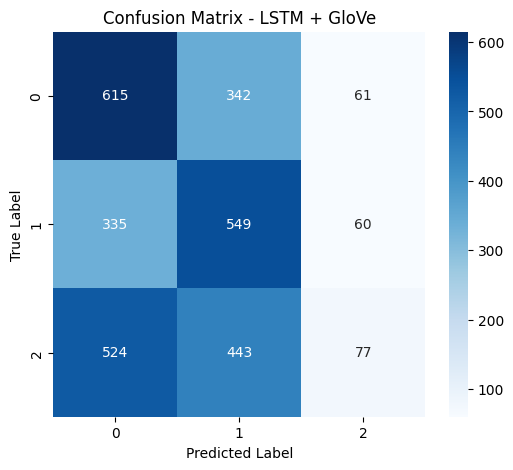

In [330]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

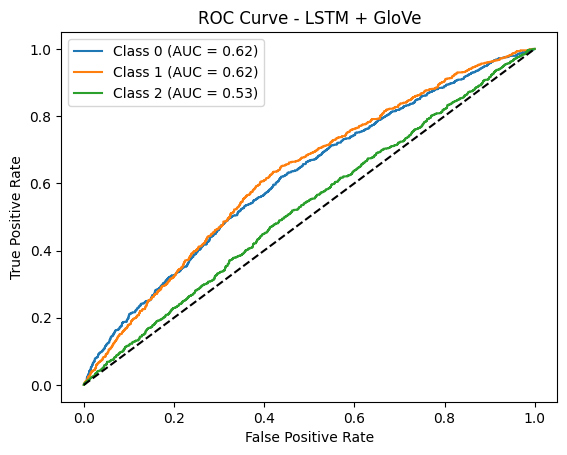

In [331]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + GloVe")

plt.legend()
plt.show()

Attention


In [386]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [387]:
input_layer = Input(shape=(max_len,))

# Embedding layer (GloVe)
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
)(input_layer)

# 🔥 LSTM with sequences (important for attention)
lstm_layer = LSTM(128, return_sequences=True)(embedding_layer)

# 🔥 Attention
attention = Attention()([lstm_layer, lstm_layer])

# 🔥 Pooling (convert sequence → vector)
pooling = GlobalMaxPooling1D()(attention)

# Dense layers
dense1 = Dense(128, activation='relu')(pooling)
dense2 = Dense(64, activation='relu')(dense1)

drop = Dropout(0.5)(dense2)

# Output
output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [388]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_24        │ (None, 100, 100)  │    935,700 │ input_layer_24[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_25 (LSTM)      │ (None, 100, 128)  │    117,248 │ embedding_24[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 100, 128)  │          0 │ lstm_25[0][0],    │
│ (Attention)         │                   │            │ lstm_25[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ attention_4[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 128)       │     16,512 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 64)        │      8,256 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 64)        │          0 │ dense_49[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 3)         │        195 │ dropout_24[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,077,911 (4.11 MB)

 Trainable params: 1,077,911 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

In [389]:
class_weights = {
    0: 1.1,
    1: 1.0,
    2: 1.8
}

In [390]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3793 - loss: 1.3328 - val_accuracy: 0.4283 - val_loss: 1.0816
Epoch 2/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4610 - loss: 1.3062 - val_accuracy: 0.4921 - val_loss: 1.0537
Epoch 3/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5080 - loss: 1.2634 - val_accuracy: 0.5511 - val_loss: 1.0020
Epoch 4/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5585 - loss: 1.2153 - val_accuracy: 0.5540 - val_loss: 0.9886
Epoch 5/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5901 - loss: 1.1672 - val_accuracy: 0.5206 - val_loss: 0.9968
Epoch 6/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5991 - loss: 1.1312 - val_accuracy: 0.5648 - val_loss: 0.9718
Epoch 7/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6133 - loss: 1.1019 - val_accuracy: 0.5825 - val_loss: 0.9595
Epoch 8/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6218 - loss: 1.0830 - val_accur

In [391]:
start_inf = time.time()
pred = model.predict(X_test)
end_inf = time.time()
inference_time = end_inf - start_inf

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Total Parameters: 1077911
Parameters (Millions): 1.077911


In [392]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

params_m = params / 1e6

In [393]:
results = []

results.append({
    "Model": "LSTM (attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [394]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  LSTM (attention)  0.428476   0.427723  0.426825  0.426511        47.036526   

   Inference Time(sec)  Parameters(M)  
0             1.915347       1.077911  


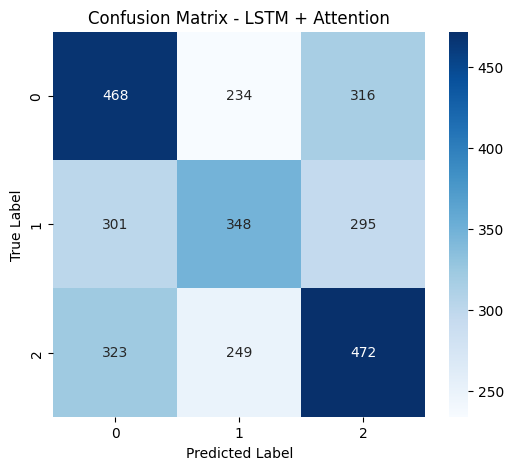

In [395]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + Attention")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

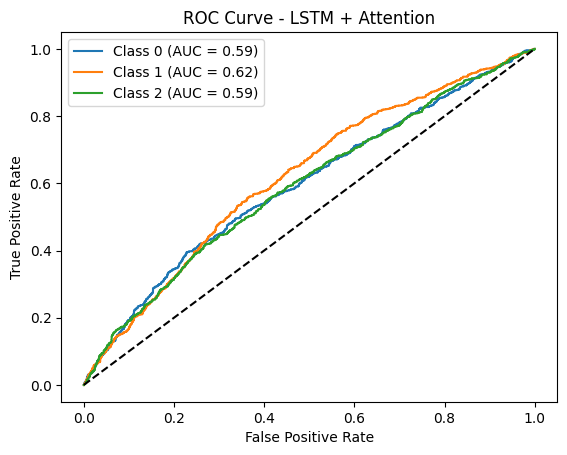

In [396]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + Attention")

plt.legend()
plt.show()

minlstm+glove

In [397]:
import time
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# MINI LSTM (smaller units)
lstm_layer = LSTM(32)(embedding_layer)

# Dropout
dropout_layer = Dropout(0.5)(lstm_layer)

# Output layer
output_layer = Dense(3, activation='softmax')(dropout_layer)

# Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_25 (Embedding)        │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 952,823 (3.63 MB)

 Trainable params: 17,123 (66.89 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [398]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [399]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4325 - loss: 1.0702 - val_accuracy: 0.3436 - val_loss: 1.1269
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4691 - loss: 1.0399 - val_accuracy: 0.3633 - val_loss: 1.1455
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4806 - loss: 1.0258 - val_accuracy: 0.3766 - val_loss: 1.1156
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4991 - loss: 1.0132 - val_accuracy: 0.3839 - val_loss: 1.1223
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5128 - loss: 0.9986 - val_accuracy: 0.3992 - val_loss: 1.1134
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5272 - loss: 0.9851 - val_accuracy: 0.4125 - val_loss: 1.1092
Epoch 7/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5348 - loss: 0.9733 - val_accuracy: 0.4075 - val_loss: 1.1256
Epoch 8/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5462 - loss: 0.9568 - val_accuracy:

In [400]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [401]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [402]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 952823
Parameters (Millions): 0.952823


In [403]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [404]:
results = []

results.append({
    "Model": "MiniLSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [405]:
# This cell previously contained code to delete entries, which led to an empty results list.
# It has been removed to prevent accidental clearing of results. Please re-run the model
# evaluation cells to populate the 'results' list with all desired model metrics.

# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  MiniLSTM (GloVe)  0.414504   0.423929  0.419333  0.366217        37.326148   

   Inference Time(sec)  Parameters(M)  
0             0.616413       1.077911  


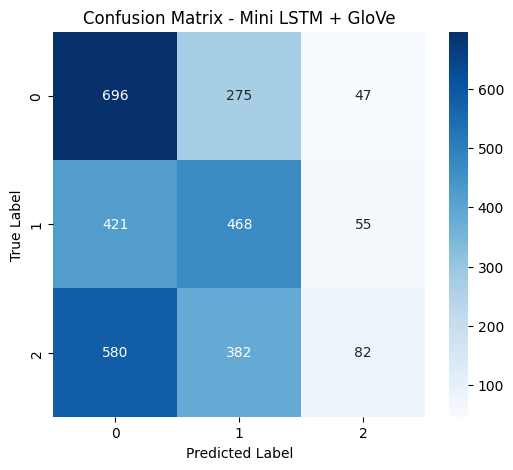

In [406]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

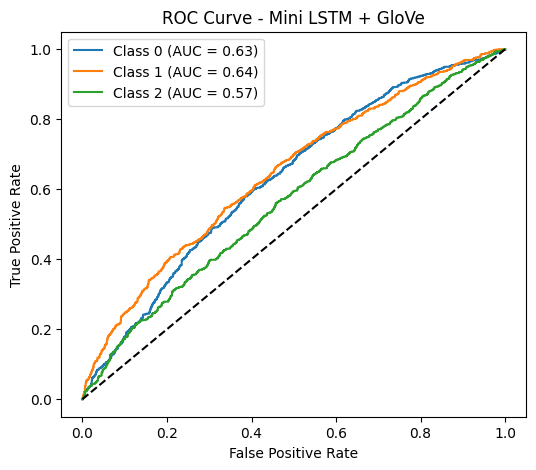

In [407]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + GloVe")

plt.legend()
plt.show()

minlstm+attention

In [444]:
input_layer = Input(shape=(max_len,))

# Embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

# 🔥 Mini LSTM (improved)
lstm_out = LSTM(96, return_sequences=True)(embedding_layer)

# 🔥 Attention
attention_out = Attention()([lstm_out, lstm_out])

# 🔥 Pooling
context = GlobalMaxPooling1D()(attention_out)

# Dense layers
dense1 = Dense(64, activation='relu')(context)
bn = BatchNormalization()(dense1)

drop = Dropout(0.5)(bn)

# Output
output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

In [445]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),   # stable LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [446]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [447]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]

)
end_train = time.time()
train_time = end_train - start_train

Epoch 1/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4234 - loss: 1.1528 - val_accuracy: 0.4536 - val_loss: 1.0602
Epoch 2/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4896 - loss: 1.0431 - val_accuracy: 0.4536 - val_loss: 1.0687
Epoch 3/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5319 - loss: 0.9940 - val_accuracy: 0.4032 - val_loss: 1.0711
Epoch 4/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5674 - loss: 0.9520 - val_accuracy: 0.5482 - val_loss: 1.0361
Epoch 5/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5963 - loss: 0.9110 - val_accuracy: 0.5252 - val_loss: 1.1066
Epoch 6/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6075 - loss: 0.8884 - val_accuracy: 0.5765 - val_loss: 0.9699
Epoch 7/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6189 - loss: 0.8654 - val_accuracy: 0.5111 - val_loss: 1.1212
Epoch 8/15
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6237 - loss: 0.8517 - val_accu

In [448]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [449]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [450]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1018007
Parameters (Millions): 1.018007


In [451]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [452]:
results = []

results.append({
    "Model": "MiniLSTM (attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [453]:
# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

                  Model  Accuracy  Precision    Recall  F1 score  \
0  MiniLSTM (attention)  0.391883   0.263737  0.396607  0.310968   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
0       840.688196             0.616165       1.077911  


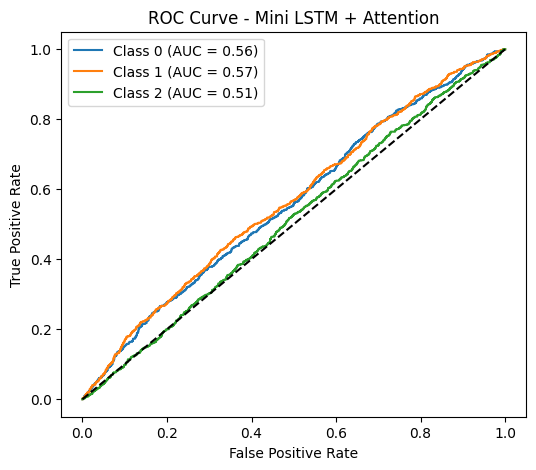

In [443]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + Attention")

plt.legend()
plt.show()

gru+glove

In [454]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# GRU layer
gru_layer = GRU(128, dropout=0.3, recurrent_dropout=0.3)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_31 (Embedding)        │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,024,407 (3.91 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [455]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [456]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 98s 295ms/step - accuracy: 0.4287 - loss: 1.0793 - val_accuracy: 0.3716 - val_loss: 1.1368
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 94s 295ms/step - accuracy: 0.4623 - loss: 1.0436 - val_accuracy: 0.3683 - val_loss: 1.1630
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 93s 293ms/step - accuracy: 0.4716 - loss: 1.0359 - val_accuracy: 0.3726 - val_loss: 1.1246
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 92s 290ms/step - accuracy: 0.4830 - loss: 1.0273 - val_accuracy: 0.3782 - val_loss: 1.1360
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 92s 290ms/step - accuracy: 0.4871 - loss: 1.0166 - val_accuracy: 0.4002 - val_loss: 1.1449


In [457]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step


In [458]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [459]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1024407
Parameters (Millions): 1.024407


In [460]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [461]:
results = []
results.append({
    "Model": "GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [462]:
# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

         Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  GRU (GloVe)  0.372588   0.413696  0.386847  0.297038       474.040767   

   Inference Time(sec)  Parameters(M)  
0             7.703668       1.024407  


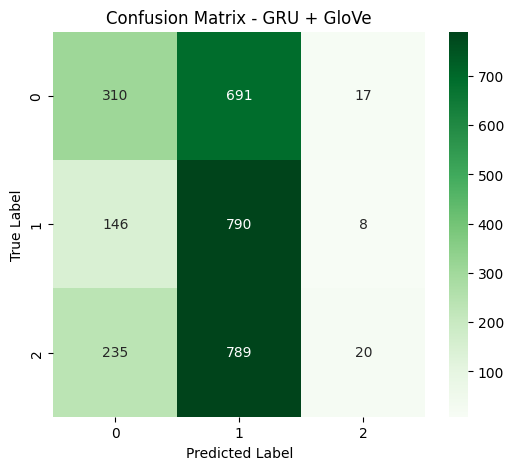

In [463]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - GRU + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

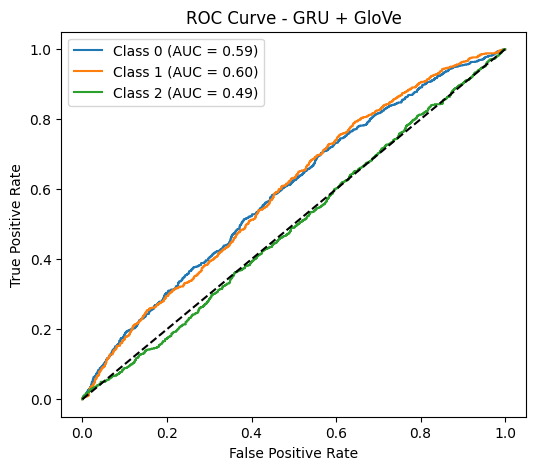

In [464]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU + GloVe")

plt.legend()
plt.show()

gru+attention

In [476]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)(input_layer)

gru_layer = GRU(128, return_sequences=True)(embedding_layer)

attention = Attention()([gru_layer, gru_layer])

pool = GlobalMaxPooling1D()(attention)

drop = Dropout(0.3)(pool)

output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_35        │ (None, 100, 100)  │    935,700 │ input_layer_35[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ (None, 100, 128)  │     88,320 │ embedding_35[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_11        │ (None, 100, 128)  │          0 │ gru_5[0][0],      │
│ (Attention)         │                   │            │ gru_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ attention_11[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 128)       │          0 │ global_max_pooli… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 3)         │        387 │ dropout_35[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,024,407 (3.91 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [477]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4551 - loss: 1.0580 - val_accuracy: 0.3530 - val_loss: 1.1272
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5042 - loss: 1.0133 - val_accuracy: 0.3480 - val_loss: 1.1393
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5495 - loss: 0.9675 - val_accuracy: 0.3739 - val_loss: 1.1460
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5746 - loss: 0.9296 - val_accuracy: 0.4215 - val_loss: 1.0793
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6067 - loss: 0.8873 - val_accuracy: 0.4428 - val_loss: 1.0645
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6317 - loss: 0.8506 - val_accuracy: 0.4701 - val_loss: 1.0527
Epoch 7/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6540 - loss: 0.8164 - val_accuracy: 0.4750 - val_loss: 1.0524
Epoch 8/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6719 - loss: 0.7858 - val_accurac

In [478]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [479]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 1024407
Parameters (Millions): 1.024407


In [480]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [481]:
results.append({
    "Model": "GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [482]:
results_df = pd.DataFrame(results)
cleaned_gru_attention = results_df[results_df['Model'] == 'GRU (GloVe + Attention)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_gru_attention)

                     Model  Accuracy  Precision    Recall  F1 score  \
2  GRU (GloVe + Attention)  0.484032   0.510117  0.486736  0.485618   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
2         38.94058             0.843448       1.024407  


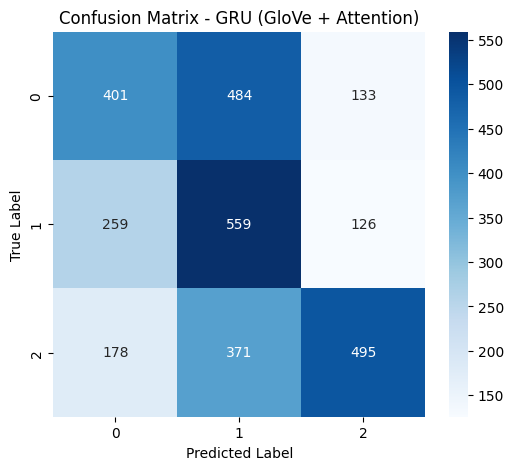

In [483]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

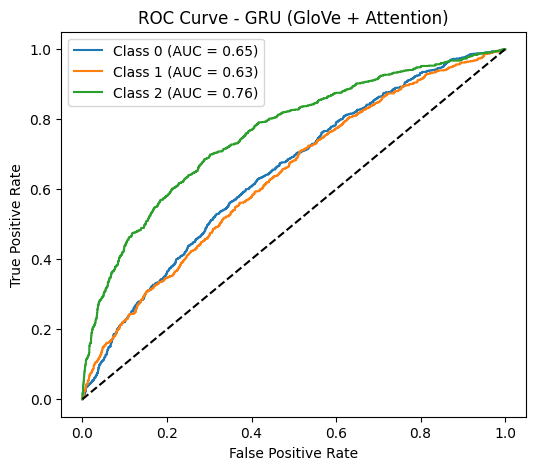

In [484]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU (GloVe + Attention)")

plt.legend()
plt.show()

mingru+glove

In [495]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_37 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_37 (Embedding)        │ (None, 100, 100)       │       935,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 32)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 948,663 (3.62 MB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [496]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4386 - loss: 1.0720 - val_accuracy: 0.3636 - val_loss: 1.1348
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4750 - loss: 1.0335 - val_accuracy: 0.3902 - val_loss: 1.1232
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4905 - loss: 1.0180 - val_accuracy: 0.3906 - val_loss: 1.1115
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5116 - loss: 0.9983 - val_accuracy: 0.3969 - val_loss: 1.1194
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5262 - loss: 0.9847 - val_accuracy: 0.3972 - val_loss: 1.1260
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5383 - loss: 0.9675 - val_accuracy: 0.3959 - val_loss: 1.1251
Epoch 7/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5550 - loss: 0.9518 - val_accuracy: 0.3929 - val_loss: 1.1305
Epoch 8/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5649 - loss: 0.9298 - val_accuracy: 

In [497]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [498]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [499]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 948663
Parameters (Millions): 0.948663


In [500]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [501]:
results.append({
    "Model": "Mini GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [502]:
results_df = pd.DataFrame(results)
cleaned_mini_gru_glove = results_df[results_df['Model'] == 'Mini GRU (GloVe)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_mini_gru_glove)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
4  Mini GRU (GloVe)  0.383234   0.376989  0.393602  0.333952         44.89977   

   Inference Time(sec)  Parameters(M)  
4             0.525572       0.948663  


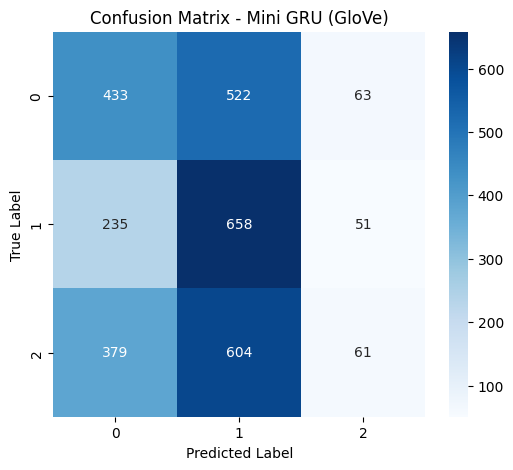

In [503]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini GRU (GloVe)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

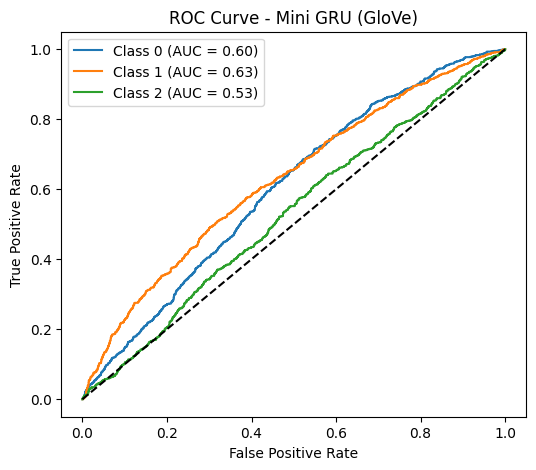

In [504]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe)")

plt.legend()
plt.show()

mingru +attention

In [505]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32, return_sequences=True)(embedding_layer)

# Attention
attention = Attention()([gru_layer, gru_layer])

# Pooling
pool = GlobalMaxPooling1D()(attention)

# Dropout
drop = Dropout(0.3)(pool)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_38      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_38        │ (None, 100, 100)  │    935,700 │ input_layer_38[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_8 (GRU)         │ (None, 100, 32)   │     12,864 │ embedding_38[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_12        │ (None, 100, 32)   │          0 │ gru_8[0][0],      │
│ (Attention)         │                   │            │ gru_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ attention_12[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 32)        │          0 │ global_max_pooli… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 3)         │         99 │ dropout_38[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 948,663 (3.62 MB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 935,700 (3.57 MB)

In [506]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4497 - loss: 1.0605 - val_accuracy: 0.3646 - val_loss: 1.1448
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4880 - loss: 1.0346 - val_accuracy: 0.3756 - val_loss: 1.1344
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4974 - loss: 1.0201 - val_accuracy: 0.3799 - val_loss: 1.0985
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5134 - loss: 1.0024 - val_accuracy: 0.3869 - val_loss: 1.1392
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5334 - loss: 0.9806 - val_accuracy: 0.3819 - val_loss: 1.1032
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5407 - loss: 0.9685 - val_accuracy: 0.3872 - val_loss: 1.1270
Epoch 7/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5574 - loss: 0.9486 - val_accuracy: 0.4015 - val_loss: 1.1067
Epoch 8/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5695 - loss: 0.9364 - val_accuracy:

In [507]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [508]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [509]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 948663
Parameters (Millions): 0.948663


In [510]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

In [511]:
results.append({
    "Model": "Mini GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [512]:
results_df = pd.DataFrame(results)
print(results_df[results_df['Model'] == 'Mini GRU (GloVe + Attention)'])

                          Model  Accuracy  Precision    Recall  F1 score  \
5  Mini GRU (GloVe + Attention)  0.403526   0.417092  0.406347  0.373806   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
5        36.430165             0.546822       0.948663  


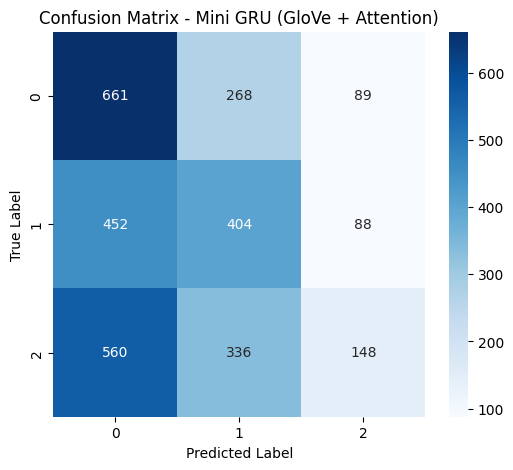

In [513]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

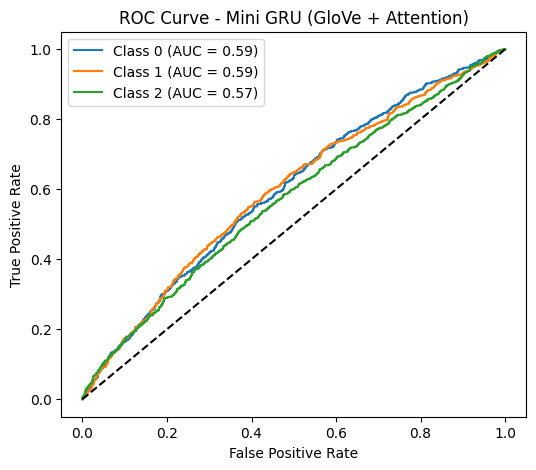

In [514]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe + Attention)")

plt.legend()
plt.show()